# 826 – Détection des Fronts Montants & Phases de Cristallisation

## Contexte

Ce notebook analyse les données de **cristallisation du procédé 826** sur plusieurs campagnes.  
L'objectif est de **détecter automatiquement les fronts montants** — les moments critiques où un cristalliseur passe en phase active de cristallisation — à partir de deux signaux clés :

| Signal | Tag | Description |
|--------|-----|-------------|
| **Niveau (LR)** | 826LR04 / 826LR05 / 826LR06 | Taux de remplissage du cristalliseur (%) |
| **Température (TRC)** | 826TRC07 / 826TRC08 / 826TRC09 | Température interne du cristalliseur (°C) |

### Les 3 cristalliseurs

| Cristalliseur | Niveau | Température |
|---------------|--------|-------------|
| Cristalliseur 1 | `826LR04` | `826TRC07` |
| Cristalliseur 2 | `826LR05` | `826TRC08` |
| Cristalliseur 3 | `826LR06` | `826TRC09` |

---

## Signature d'un Front Montant

Un front montant est identifié par la séquence suivante :

```
[T-2h]  LR ≈ 0-20%  |  TRC commence à monter (+5°C/h)
[T-1h]  LR monte rapidement vers 50%  |  TRC en forte hausse
[T=0]   LR franchit 50%  ←  POINT CRITIQUE (marqué en rouge)
[T+1h]  LR se stabilise >50%  |  TRC redescend rapidement vers ~30°C
```

> **Règle de découpe :** 5 min avant le point critique / 15-16 min après  
> *(en données horaires agrégées : fenêtre de ±2h)*


## 1. Imports & Configuration

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import numpy as np
import types
from pathlib import Path
from botocore.client import Config
import ibm_boto3

# ── Fonction helper COS ─────────────────────────────────────────────────────
def load_from_cos(object_key):
    cos_client = ibm_boto3.client(
        service_name='s3',
        ibm_api_key_id='u0Q89Kc_BcbdCjkhvcljD3OzFL5W75mnEdawOrS0DIXs',
        ibm_auth_endpoint="https://iam.cloud.ibm.com/identity/token",
        config=Config(signature_version='oauth'),
        endpoint_url='https://s3.direct.ca-tor.cloud-object-storage.appdomain.cloud'
    )

    bucket = '826unitcristallisation-donotdelete-pr-lzv7mn7pitwhsv'
    body = cos_client.get_object(Bucket=bucket, Key=object_key)['Body']

    # fix pandas compatibility
    if not hasattr(body, "__iter__"):
        body.__iter__ = types.MethodType(lambda self: 0, body)

    return pd.read_csv(body)

# ── Chargement datasets ─────────────────────────────────────────────────────
df_C5 = load_from_cos('T826_CRYSTALLIZER_202603_CAMPAIGN_5_PIVOTBYHOUR.csv')
df_C6 = load_from_cos('T826_CRYSTALLIZER_202603_CAMPAIGN_6_PIVOTBYHOUR.csv')
df_C7 = load_from_cos('T826_CRYSTALLIZER_202603_CAMPAIGN_7_PIVOTBYHOUR.csv')
df_C8 = load_from_cos('T826_CRYSTALLIZER_202603_CAMPAIGN_8_PIVOTBYHOUR.csv')

# ── Uniformisation timestamps (IMPORTANT pour tes plots) ───────────────────
for df in [df_C5, df_C6, df_C7, df_C8]:
    df["ts"] = pd.to_datetime(df["INSTRUMENT_TAG_TS"], format="%Y-%m-%d %H")

# ── Structure propre (IMPORTANT pour ton pipeline) ─────────────────────────
all_results = {
    "Campaign 5": df_C5,
    "Campaign 6": df_C6,
    "Campaign 7": df_C7,
    "Campaign 8": df_C8,
}

# ── Mapping cristalliseurs ─────────────────────────────────────────────────
CRYSTALLIZERS = {
    "Cristalliseur 1": {"lr": "AVG_826LR04", "trc": "AVG_826TRC07", "deltat": "AVG_826TRC07_DELTAT"},
    "Cristalliseur 2": {"lr": "AVG_826LR05", "trc": "AVG_826TRC08", "deltat": "AVG_826TRC08_DELTAT"},
    "Cristalliseur 3": {"lr": "AVG_826LR06", "trc": "AVG_826TRC09", "deltat": "AVG_826TRC09_DELTAT"},
}

# ── Couleurs ───────────────────────────────────────────────────────────────
COLORS_LR  = ["#3B0DA8", "#777777", "#90EE90"]
COLORS_TRC = ["#22CC00", "#444444", "#CC88CC"]

# ── Seuils ────────────────────────────────────────────────────────────────
LR_THRESHOLD   = 50
TRC_SURGE_RATE = 5.0
WINDOW_BEFORE  = 2
WINDOW_AFTER   = 2

print("✅ Données chargées et structurées correctement")

✅ Configuration chargée
   Répertoire données : C:\Users\MohamedNadirHAMOU\OneDrive - IBM\Desktop\PROJET_IBM_REJU\Data2
   Seuil LR           : > 50%
   Seuil montée TRC   : > 5.0 °C/h sur 2h glissantes
   Fenêtre critique   : ±2h autour du front


## 2. Chargement & Aperçu des Données

Les fichiers sont au format **PIVOTBYHOUR** : chaque ligne représente une heure d'agrégation.  
Pour chaque tag, on dispose de : `MIN`, `AVG`, `MAX`, `STDDEV` — on utilisera principalement les colonnes `AVG_*`.


In [ ]:
# ── Fonction load (si besoin pour reusabilité) ────────────────────────────
def load_campaign(df):
    """Prépare une campagne déjà chargée."""
    df = df.copy()
    df["ts"] = pd.to_datetime(df["INSTRUMENT_TAG_TS"], format="%Y-%m-%d %H")
    df = df.sort_values("ts").reset_index(drop=True)
    return df

# ── Construction dataset propre ───────────────────────────────────────────
df_C5 = load_campaign(df_C5)
df_C6 = load_campaign(df_C6)
df_C7 = load_campaign(df_C7)
df_C8 = load_campaign(df_C8)

all_results = {
    "Campaign 5": df_C5,
    "Campaign 6": df_C6,
    "Campaign 7": df_C7,
    "Campaign 8": df_C8,
}

# ── Aperçu Campaign 5 ─────────────────────────────────────────────────────
df_preview = all_results["Campaign 5"]

print(f"Dimensions : {df_preview.shape[0]} lignes × {df_preview.shape[1]} colonnes")
print(f"Période    : {df_preview['ts'].min().date()}  →  {df_preview['ts'].max().date()}")
print()

# ── Colonnes LR / TRC ─────────────────────────────────────────────────────
relevant_cols = [
    c for c in df_preview.columns
    if c.startswith("AVG") and any(x in c for x in ["LR04","LR05","LR06","TRC07","TRC08","TRC09"])
]

print("Colonnes AVG utilisées :")
for c in relevant_cols:
    series = df_preview[c].dropna()
    print(f"  {c:<30}  min={series.min():6.1f}  max={series.max():6.1f}  moy={series.mean():6.1f}")

Dimensions : 374 lignes × 66 colonnes
Période    : 2025-08-27  →  2025-09-12

Colonnes AVG utilisées :
  AVG_826LR04                     min=  -0.0  max=  78.6  moy=  19.1
  AVG_826LR05                     min=  -0.0  max=  78.9  moy=  13.6
  AVG_826LR06                     min=  -0.0  max=  91.0  moy=  11.3
  AVG_826TRC07                    min=  12.9  max=  94.6  moy=  40.9
  AVG_826TRC07_DELTAT             min=  -0.6  max=   1.1  moy=  -0.0
  AVG_826TRC08                    min=  15.2  max=  88.3  moy=  38.3
  AVG_826TRC08_DELTAT             min=  -0.3  max=   0.7  moy=  -0.0
  AVG_826TRC09                    min=  20.2  max= 100.5  moy=  44.2
  AVG_826TRC09_DELTAT             min=  -0.2  max=   0.6  moy=  -0.0


In [ ]:
# Résumé de toutes les campagnes
print(f"{'Campagne':<14} {'Début':<20} {'Fin':<20} {'Nb lignes':>10}")
print("-" * 70)

for name, df in all_results.items():
    print(
        f"{name:<14} "
        f"{str(df['ts'].min().date()):<20} "
        f"{str(df['ts'].max().date()):<20} "
        f"{len(df):>10}"
    )

Campagne       Début         Fin           Nb heures
----------------------------------------------------
Campaign 5     2025-08-27    2025-09-12          374
Campaign 6     2025-11-02    2025-11-22          464
Campaign 7     2025-11-30    2025-12-10          240
Campaign 8     2026-01-15    2026-03-03         1128


## 3. Algorithme de Détection des Fronts Montants

### Logique

L'analyse de la **Campaign 5** a permis d'identifier la signature typique d'un front montant :

| Heure relative | LR (niveau) | TRC (température) |
|----------------|-------------|-------------------|
| T−2h | ~0–20% | début de montée (+3 à +5°C/h) |
| T−1h | ~5–25% | forte hausse (+10 à +30°C/h) |
| **T=0** | **franchit 50%** ↑ | **pic (~75–90°C)** |
| T+1h | se stabilise >50% | redescente rapide (−8 à −12°C/h) |
| T+3h | >50% | retour vers ~30°C |

### Critères retenus

```python
# 1. Franchissement du niveau 50% à la hausse
lr_cross_up = (LR > 50) & (LR[t-1] <= 50)

# 2. Forte montée de température dans les 2h précédentes
trc_surge = max(diff(TRC), fenêtre 2h glissante) > 5.0 °C/h

# Front montant détecté si les deux conditions sont vraies simultanément
front_montant = lr_cross_up AND trc_surge
```


In [ ]:
def detect_fronts(df, lr_col, trc_col):
    """
    Détecte les fronts montants dans une série temporelle.

    Critères :
      - LR franchit 50% à la hausse
      - TRC a une montée > 5°C/h sur une fenêtre de 2h

    Retourne la liste des indices (position dans df).
    """
    df = df.sort_values("ts").reset_index(drop=True)

    lr = df[lr_col].fillna(0)
    trc = df[trc_col].fillna(0)

    # 1) franchissement LR > seuil
    lr_cross_up = (lr > LR_THRESHOLD) & (lr.shift(1, fill_value=0) <= LR_THRESHOLD)

    # 2) pente TRC sur 2h
    trc_diff = trc.diff()
    trc_surge = trc_diff.rolling(2, min_periods=1).max() > TRC_SURGE_RATE

    crit = lr_cross_up & trc_surge

    return df.index[crit].tolist()


# ── Vérification sur toutes les campagnes ────────────────────────────────────
print(f"{'Campagne':<14} {'Cristalliseur':<18} {'Nb fronts':>9}  {'Dates détectées'}")
print("-" * 90)

all_results = {}

for camp_name, df in all_results.items():
    all_results[camp_name] = {"df": df, "fronts": {}}

    for cryst_name, tags in CRYSTALLIZERS.items():
        idxs = detect_fronts(df, tags["lr"], tags["trc"])
        all_results[camp_name]["fronts"][cryst_name] = idxs

        dates = ", ".join([str(df["ts"].iloc[i])[:13] for i in idxs]) if idxs else "—"
        print(f"{camp_name:<14} {cryst_name:<18} {len(idxs):>9}  {dates}")

    print()

Campagne       Cristalliseur      Nb fronts  Dates détectées
------------------------------------------------------------------------------------------
Campaign 5     Cristalliseur 1            5  2025-08-30 09, 2025-09-01 20, 2025-09-02 12, 2025-09-03 20, 2025-09-04 19
Campaign 5     Cristalliseur 2            3  2025-08-30 20, 2025-09-02 05, 2025-09-02 21
Campaign 5     Cristalliseur 3            3  2025-08-29 20, 2025-08-31 06, 2025-09-03 07

Campaign 6     Cristalliseur 1            2  2025-11-11 08, 2025-11-11 22
Campaign 6     Cristalliseur 2            2  2025-11-10 22, 2025-11-11 16
Campaign 6     Cristalliseur 3            2  2025-11-06 22, 2025-11-11 03

Campaign 7     Cristalliseur 1            1  2025-12-08 17
Campaign 7     Cristalliseur 2            1  2025-12-09 08
Campaign 7     Cristalliseur 3            1  2025-12-10 04

Campaign 8     Cristalliseur 1            8  2026-01-29 08, 2026-02-10 14, 2026-02-13 19, 2026-02-16 10, 2026-02-17 13, 2026-02-21 18, 2026-02-26 22,

## 4. Visualisation

Chaque campagne est représentée par **deux subplots** :
- **Graphe du haut** : vue d'ensemble — tous les niveaux (LR) et températures (TRC) des 3 cristalliseurs
- **Graphe du bas** : même données avec les **points rouges** sur les fronts montants détectés et les **zones critiques** surlignées

Les points rouges marquent l'instant exact où le front est détecté (T=0).  
La zone rouge translucide couvre la fenêtre ±2h autour du front.


In [ ]:
def plot_campaign(campaign_name, df, fronts_by_cryst):
    """
    Génère le graphe double-subplot pour une campagne.
    Retourne la figure matplotlib.
    """
    df = df.sort_values("ts").reset_index(drop=True)

    fig, (ax_top, ax_bot) = plt.subplots(
        2, 1, figsize=(18, 10), sharex=True,
        gridspec_kw={"hspace": 0.10}
    )
    fig.patch.set_facecolor("#F8F8F8")

    for ax in [ax_top, ax_bot]:
        ax.set_facecolor("#FAFAFA")
        ax.grid(True, linestyle="--", linewidth=0.4, color="#CCCCCC", zorder=0)
        ax.set_ylabel("Valeur", fontsize=10)
        ax.spines[["top", "right"]].set_visible(False)

    ts = df["ts"]
    legend_elements = []

    for i, (cryst_name, tags) in enumerate(CRYSTALLIZERS.items()):
        lr_col  = tags["lr"]
        trc_col = tags["trc"]

        lr  = df[lr_col]
        trc = df[trc_col]

        c_lr  = COLORS_LR[i]
        c_trc = COLORS_TRC[i]

        label_lr  = lr_col.replace("AVG_", "")
        label_trc = trc_col.replace("AVG_", "")

        ax_top.plot(ts, lr,  color=c_lr,  linewidth=1.4, label=label_lr)
        ax_top.plot(ts, trc, color=c_trc, linewidth=1.4, label=label_trc)

        ax_bot.plot(ts, lr,  color=c_lr,  linewidth=1.4, alpha=0.35)
        ax_bot.plot(ts, trc, color=c_trc, linewidth=2.2)

        legend_elements.append(mpatches.Patch(color=c_lr,  label=label_lr))
        legend_elements.append(mpatches.Patch(color=c_trc, label=label_trc))

        # ── Fronts ───────────────────────────────────────────────────────────
        for idx in fronts_by_cryst.get(cryst_name, []):
            if idx >= len(df):
                continue

            t_crit  = ts.iloc[idx]
            t_start = t_crit - pd.Timedelta(hours=WINDOW_BEFORE)
            t_end   = t_crit + pd.Timedelta(hours=WINDOW_AFTER)

            for ax in [ax_top, ax_bot]:
                ax.axvspan(t_start, t_end, color="red", alpha=0.07, zorder=1)
                ax.axvline(t_crit, color="red", linewidth=0.9, linestyle="--", alpha=0.45, zorder=2)

            ax_bot.scatter(t_crit, trc.iloc[idx], color="red", s=90, zorder=6,
                           marker="o", edgecolors="darkred", linewidths=1.2)
            ax_bot.scatter(t_crit, lr.iloc[idx], color="red", s=90, zorder=6,
                           marker="o", edgecolors="darkred", linewidths=1.2)

    # ── Légende ─────────────────────────────────────────────────────────────
    legend_elements.append(
        mpatches.Patch(color="red", alpha=0.6, label="Front montant (critique)")
    )

    ax_top.legend(handles=legend_elements[:-1], loc="upper right",
                  fontsize=8.5, framealpha=0.85, ncol=3)

    ax_bot.legend(handles=legend_elements, loc="upper right",
                  fontsize=8.5, framealpha=0.85, ncol=4)

    # ── Axe X ───────────────────────────────────────────────────────────────
    ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
    ax_bot.xaxis.set_major_locator(mdates.DayLocator(interval=1))
    fig.autofmt_xdate(rotation=0, ha="center")
    ax_bot.set_xlabel("Temps", fontsize=11)

    # ── Seuil LR ────────────────────────────────────────────────────────────
    for ax in [ax_top, ax_bot]:
        ax.axhline(50, color="orange", linewidth=0.8, linestyle=":", alpha=0.7)

    ax_top.set_title(
        f"826 – Cristallisation  |  {campaign_name}\n"
        f"Niveaux (LR) & Températures (TRC) — Fronts montants",
        fontsize=13, fontweight="bold", pad=12
    )

    plt.tight_layout()
    return fig

print("✅ Fonction plot_campaign corrigée")

✅ Fonction plot_campaign définie


## 5. Résultats par Campagne

### Campaign 5  ·  août – septembre 2025

La Campaign 5 est la plus active en termes de cycles de cristallisation.  
On observe **une alternance régulière** entre les 3 cristalliseurs, typique d'un procédé en séquence décalée.  
Le **Cristalliseur 1** (LR04/TRC07) présente le plus grand nombre de fronts (5), 
suggérant qu'il est le cristalliseur primaire de cette campagne.


C:\Users\MohamedNadirHAMOU\AppData\Local\Temp\ipykernel_3596\3650013396.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


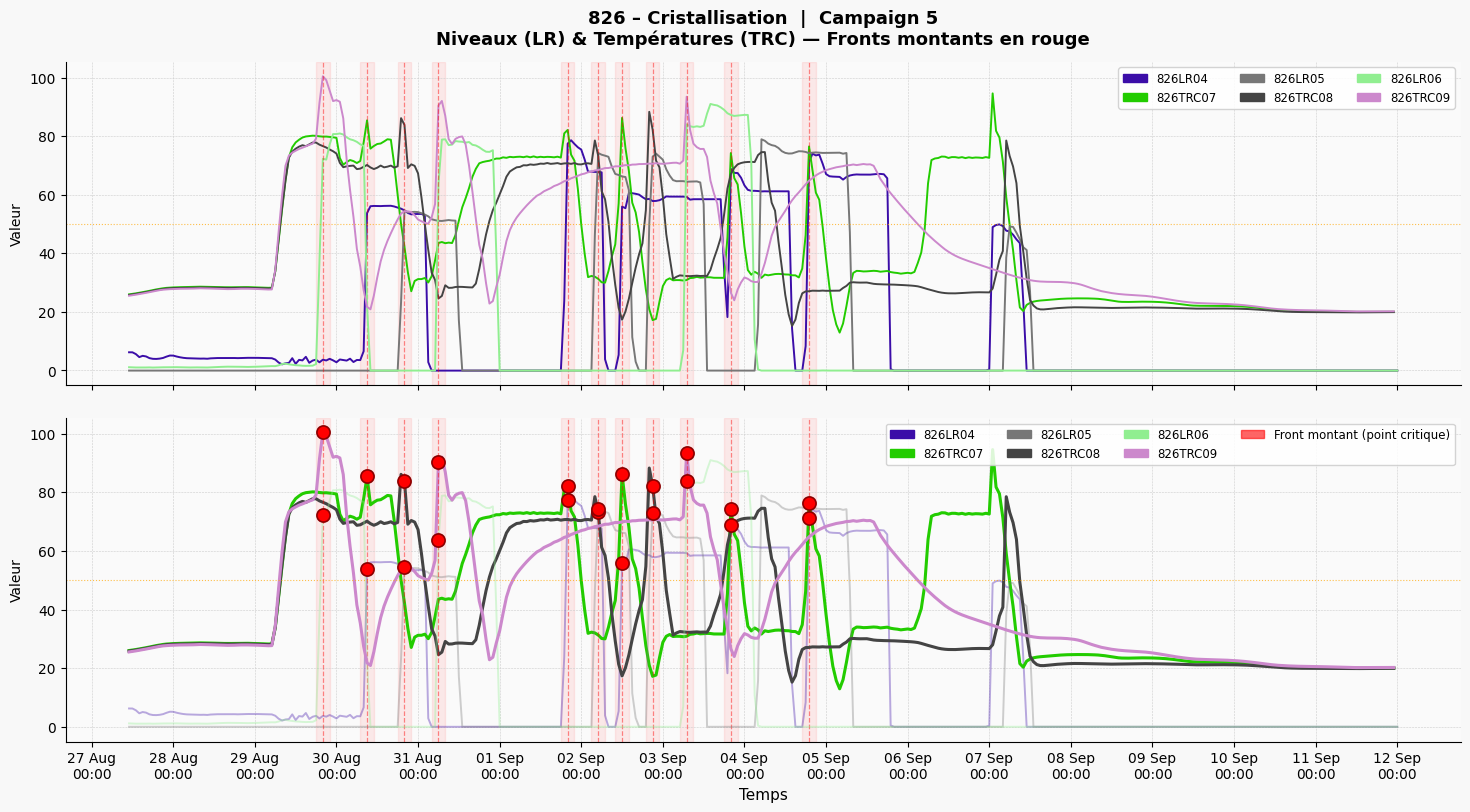


📋 Fronts détectés — Campaign 5
  Cristalliseur 1 : 5 front(s)
    → 2025-08-30 09:00  |  LR=53.7%  TRC=85.4°C
    → 2025-09-01 20:00  |  LR=77.4%  TRC=82.1°C
    → 2025-09-02 12:00  |  LR=56.0%  TRC=86.3°C
    → 2025-09-03 20:00  |  LR=68.8%  TRC=74.3°C
    → 2025-09-04 19:00  |  LR=71.1%  TRC=76.5°C
  Cristalliseur 2 : 3 front(s)
    → 2025-08-30 20:00  |  LR=54.6%  TRC=83.9°C
    → 2025-09-02 05:00  |  LR=74.2%  TRC=73.2°C
    → 2025-09-02 21:00  |  LR=73.0%  TRC=82.2°C
  Cristalliseur 3 : 3 front(s)
    → 2025-08-29 20:00  |  LR=72.3%  TRC=100.5°C
    → 2025-08-31 06:00  |  LR=63.7%  TRC=90.5°C
    → 2025-09-03 07:00  |  LR=84.1%  TRC=93.5°C


In [ ]:
camp = "Campaign 5"

res = all_results[camp]

fig = plot_campaign(camp, res["df"], res["fronts"])
plt.show()

# ── Résumé des fronts détectés ───────────────────────────────────────────
print(f"\n📋 Fronts détectés — {camp}")

df = res["df"]

for cryst, idxs in res["fronts"].items():
    print(f"  {cryst} : {len(idxs)} front(s)")

    lr_col  = CRYSTALLIZERS[cryst]["lr"]
    trc_col = CRYSTALLIZERS[cryst]["trc"]

    for idx in idxs:
        if idx >= len(df):
            continue

        row = df.iloc[idx]

        print(
            f"    → {str(row['ts'])[:16]}  |  "
            f"LR={row[lr_col]:.1f}%  |  TRC={row[trc_col]:.1f}°C"
        )

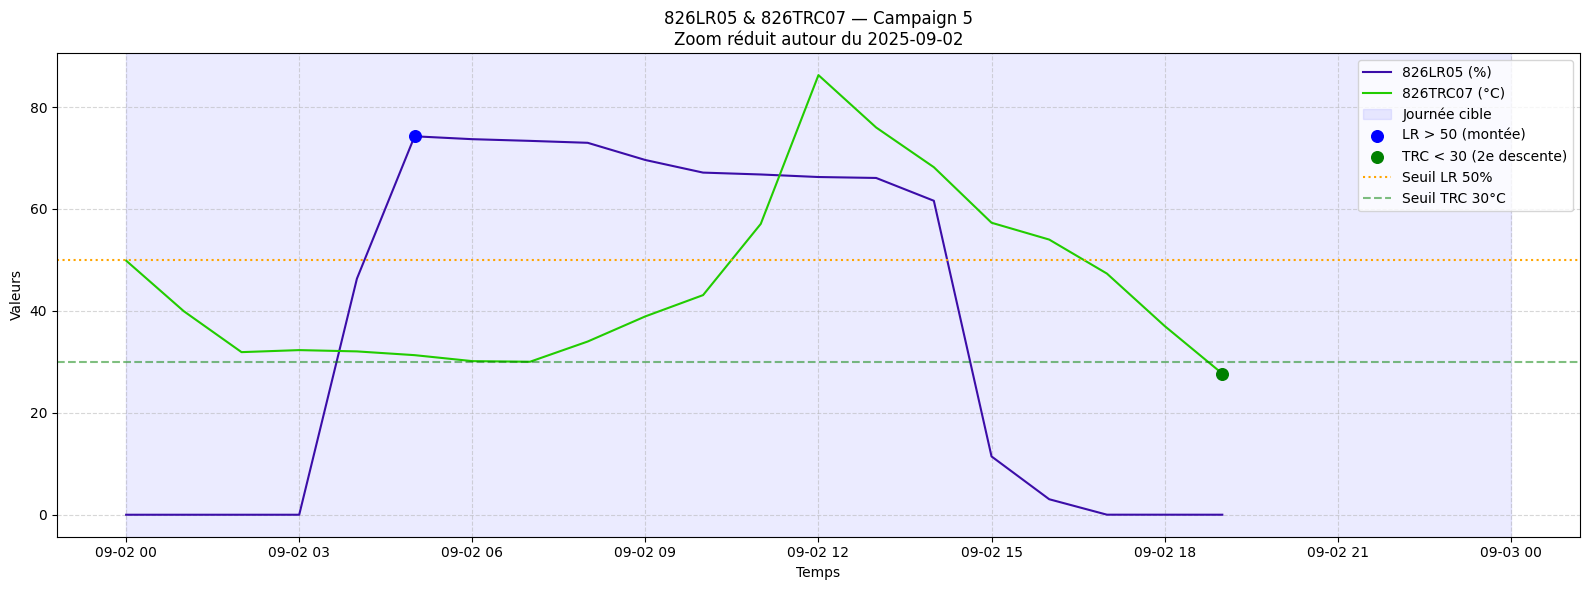


📋 Fronts détectés autour du 2025-09-02 :

 Points LR > 50 : 1
 Points TRC < 30 (2e événement) : 1


In [ ]:
# ── VISU CIBLÉE AVEC POINTS MÉTIER ────────────────────────────────────────

camp = "Campaign 5"
date_cible = "2025-09-02"

df = all_results[camp]["df"].copy()

lr_col  = "AVG_826LR05"
trc_col = "AVG_826TRC07"

# ── Fenêtre réduite ───────────────────────────────────────────────────────
date_dt = pd.to_datetime(date_cible)

start = date_dt - pd.Timedelta(hours=0.25)
end   = date_dt + pd.Timedelta(hours=19)

df_zoom = df[(df["ts"] >= start) & (df["ts"] <= end)].reset_index(drop=True)

# ── Détection fronts ──────────────────────────────────────────────────────
fronts = detect_fronts(df_zoom, lr_col, trc_col)

lr = df_zoom[lr_col]
trc = df_zoom[trc_col]

# ── LR > 50 (montée) ──────────────────────────────────────────────────────
lr_cross = (lr > 50) & (lr.shift(1, fill_value=0) <= 50)
lr_points_idx = df_zoom.index[lr_cross]

# ── TRC < 30 (descente) ───────────────────────────────────────────────────
trc_cross_down = (trc < 30) & (trc.shift(1, fill_value=100) >= 30)

trc_all_idx = df_zoom.index[trc_cross_down].tolist()

# ⚠️ on prend uniquement le 2e événement TRC < 30
trc_points_idx = trc_all_idx[1:2] if len(trc_all_idx) >= 2 else []

# ── Plot ──────────────────────────────────────────────────────────────────
plt.figure(figsize=(16,6))

plt.plot(df_zoom["ts"], lr, label="826LR05 (%)", color="#3B0DA8")
plt.plot(df_zoom["ts"], trc, label="826TRC07 (°C)", color="#22CC00")

# Journée cible
plt.axvspan(date_dt, date_dt + pd.Timedelta(days=1),
            color="blue", alpha=0.08, label="Journée cible")

# ── Fronts ────────────────────────────────────────────────────────────────
for idx in fronts:
    t_crit  = df_zoom["ts"].iloc[idx]
    t_start = t_crit - pd.Timedelta(hours=2)
    t_end   = t_crit + pd.Timedelta(hours=24)

    plt.axvspan(t_start, t_end, color="red", alpha=0.12)
    plt.axvline(t_crit, color="red", linestyle="--", linewidth=1)

    plt.scatter(t_crit, lr.iloc[idx], color="red", zorder=6)
    plt.scatter(t_crit, trc.iloc[idx], color="red", zorder=6)

# ── Points LR > 50 ────────────────────────────────────────────────────────
plt.scatter(df_zoom["ts"].iloc[lr_points_idx],
            lr.iloc[lr_points_idx],
            color="blue", s=70, label="LR > 50 (montée)", zorder=7)

# ── 2e TRC < 30 uniquement ────────────────────────────────────────────────
plt.scatter(df_zoom["ts"].iloc[trc_points_idx],
            trc.iloc[trc_points_idx],
            color="green", s=70, label="TRC < 30 (2e événement)", zorder=7)

# ── Style ─────────────────────────────────────────────────────────────────
plt.axhline(50, color="orange", linestyle=":", label="Seuil LR 50%")
plt.axhline(30, color="green", linestyle="--", alpha=0.5, label="Seuil TRC 30°C")

plt.title(f"826LR05 & 826TRC07 — {camp}\nZoom réduit autour du {date_cible}")
plt.xlabel("Temps")
plt.ylabel("Valeurs")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# ── Résumé ────────────────────────────────────────────────────────────────
print(f"\n📋 Fronts détectés autour du {date_cible} :")
for idx in fronts:
    row = df_zoom.iloc[idx]
    print(f"→ {row['ts']} | LR={row[lr_col]:.1f}% | TRC={row[trc_col]:.1f}°C")

print(f"\nPoints LR > 50 : {len(lr_points_idx)}")
print(f"Points TRC < 30 (2e événement) : {len(trc_points_idx)}")

C:\Users\MohamedNadirHAMOU\AppData\Local\Temp\ipykernel_3596\3308748303.py:59: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


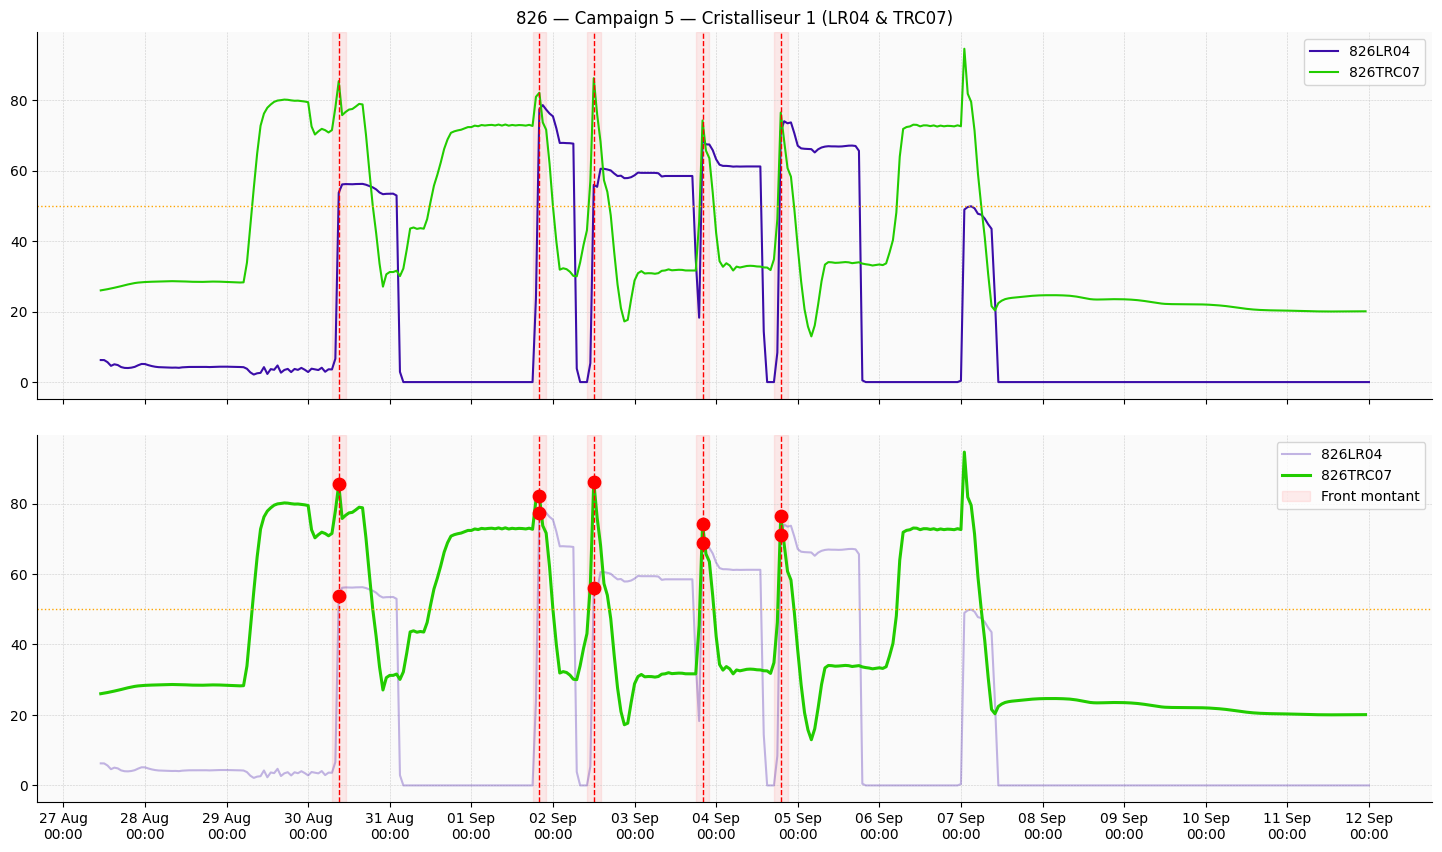

In [ ]:
# ── VISU GLOBALE (1 cristalliseur) ────────────────────────────────────────

camp = "Campaign 5"

df = all_results[camp]["df"].copy()

# sécurité tri temps
df = df.sort_values("ts").reset_index(drop=True)

fronts = all_results[camp]["fronts"]["Cristalliseur 1"]

lr_col  = "AVG_826LR04"
trc_col = "AVG_826TRC07"

ts  = df["ts"]
lr  = df[lr_col]
trc = df[trc_col]

fig, (ax_top, ax_bot) = plt.subplots(
    2, 1, figsize=(18, 10), sharex=True,
    gridspec_kw={"hspace": 0.10}
)

# ── Style ─────────────────────────────────────────────────────────────────
for ax in [ax_top, ax_bot]:
    ax.set_facecolor("#FAFAFA")
    ax.grid(True, linestyle="--", linewidth=0.4, color="#CCCCCC")
    ax.spines[["top", "right"]].set_visible(False)

# ── Tracé ─────────────────────────────────────────────────────────────────
ax_top.plot(ts, lr,  color="#3B0DA8", linewidth=1.5, label="826LR04")
ax_top.plot(ts, trc, color="#22CC00", linewidth=1.5, label="826TRC07")

ax_bot.plot(ts, lr,  color="#3B0DA8", linewidth=1.5, alpha=0.3)
ax_bot.plot(ts, trc, color="#22CC00", linewidth=2.2)

# ── Fronts ───────────────────────────────────────────────────────────────
for idx in fronts:
    if idx >= len(df):
        continue

    t_crit  = ts.iloc[idx]
    t_start = t_crit - pd.Timedelta(hours=WINDOW_BEFORE)
    t_end   = t_crit + pd.Timedelta(hours=WINDOW_AFTER)

    for ax in [ax_top, ax_bot]:
        ax.axvspan(t_start, t_end, color="red", alpha=0.07)
        ax.axvline(t_crit, color="red", linestyle="--", linewidth=1)

    ax_bot.scatter(t_crit, trc.iloc[idx], color="red", s=80, zorder=5)
    ax_bot.scatter(t_crit, lr.iloc[idx],  color="red", s=80, zorder=5)

# ── Seuil ─────────────────────────────────────────────────────────────────
for ax in [ax_top, ax_bot]:
    ax.axhline(50, color="orange", linestyle=":", linewidth=1)

# ── Légende ──────────────────────────────────────────────────────────────
ax_top.legend(loc="upper right")

ax_bot.legend(
    handles=[
        plt.Line2D([0], [0], color="#3B0DA8", label="826LR04"),
        plt.Line2D([0], [0], color="#22CC00", label="826TRC07"),
        plt.Line2D([0], [0], color="red", linestyle="--", label="Front montant"),
    ],
    loc="upper right"
)

# ── Axe temps ─────────────────────────────────────────────────────────────
ax_bot.xaxis.set_major_formatter(mdates.DateFormatter("%d %b\n%H:%M"))
ax_bot.xaxis.set_major_locator(mdates.DayLocator(interval=1))

ax_top.set_title(f"826 — {camp} — Cristalliseur 1 (LR04 & TRC07)")

plt.tight_layout()
plt.show()

### Campaign 6  ·  novembre 2025

La Campaign 6 présente **moins de cycles** que la C5 sur une durée similaire (~3 semaines).  
Chaque cristalliseur effectue 2 cycles, ce qui indique un procédé plus espacé ou des lots plus longs.  
On notera que les 3 cristalliseurs déclenchent leurs fronts dans une **fenêtre de 48h** (10-11 nov.),
révélant une phase de charge groupée.


C:\Users\MohamedNadirHAMOU\AppData\Local\Temp\ipykernel_12948\3650013396.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


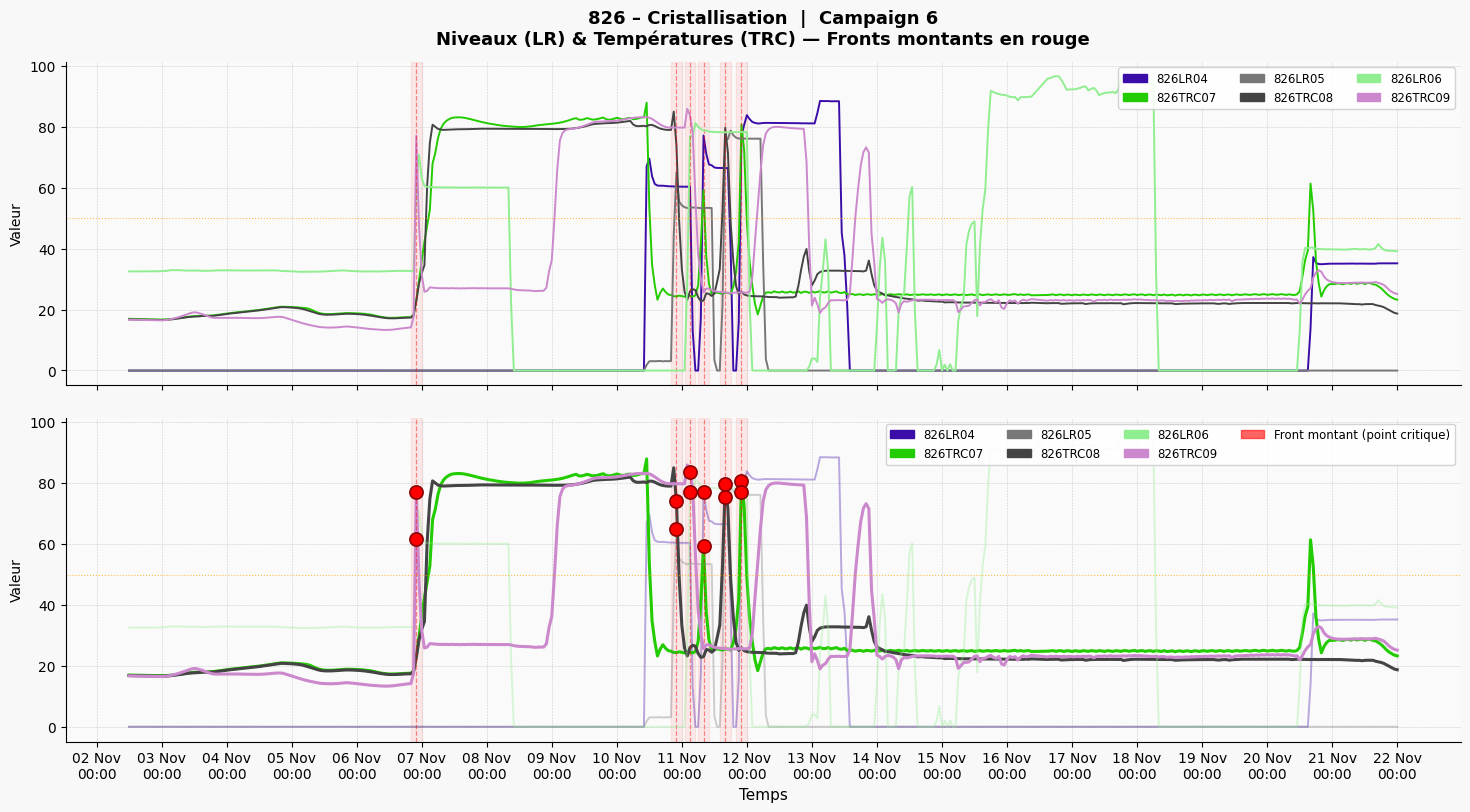


📋 Fronts détectés — Campaign 6
  Cristalliseur 1 : 2 front(s)
    → 2025-11-11 08:00  |  LR=77.2%  TRC=59.3°C
    → 2025-11-11 22:00  |  LR=77.2%  TRC=80.9°C
  Cristalliseur 2 : 2 front(s)
    → 2025-11-10 22:00  |  LR=65.0%  TRC=74.0°C
    → 2025-11-11 16:00  |  LR=75.6%  TRC=79.7°C
  Cristalliseur 3 : 2 front(s)
    → 2025-11-06 22:00  |  LR=61.7%  TRC=77.2°C
    → 2025-11-11 03:00  |  LR=77.0%  TRC=83.9°C


In [ ]:
camp = "Campaign 6"

res = all_results[camp]

fig = plot_campaign(camp, res["df"], res["fronts"])
plt.show()

print(f"\n📋 Fronts détectés — {camp}")

df = res["df"]

for cryst, idxs in res["fronts"].items():
    print(f"  {cryst} : {len(idxs)} front(s)")

    lr_col  = CRYSTALLIZERS[cryst]["lr"]
    trc_col = CRYSTALLIZERS[cryst]["trc"]

    for idx in idxs:
        if idx >= len(df):
            continue

        row = df.iloc[idx]

        print(
            f"    → {str(row['ts'])[:16]}  |  "
            f"LR={row[lr_col]:.1f}%  |  TRC={row[trc_col]:.1f}°C"
        )

### Campaign 7  ·  décembre 2025

La Campaign 7 est la **plus courte** (~10 jours) et ne présente qu'**un seul front par cristalliseur**.  
Cela peut indiquer une campagne de maintenance, un essai limité, ou une interruption prématurée.  
Les 3 fronts sont espacés d'environ **12h chacun**, ce qui correspond à un remplissage séquentiel contrôlé.


C:\Users\MohamedNadirHAMOU\AppData\Local\Temp\ipykernel_12948\3650013396.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


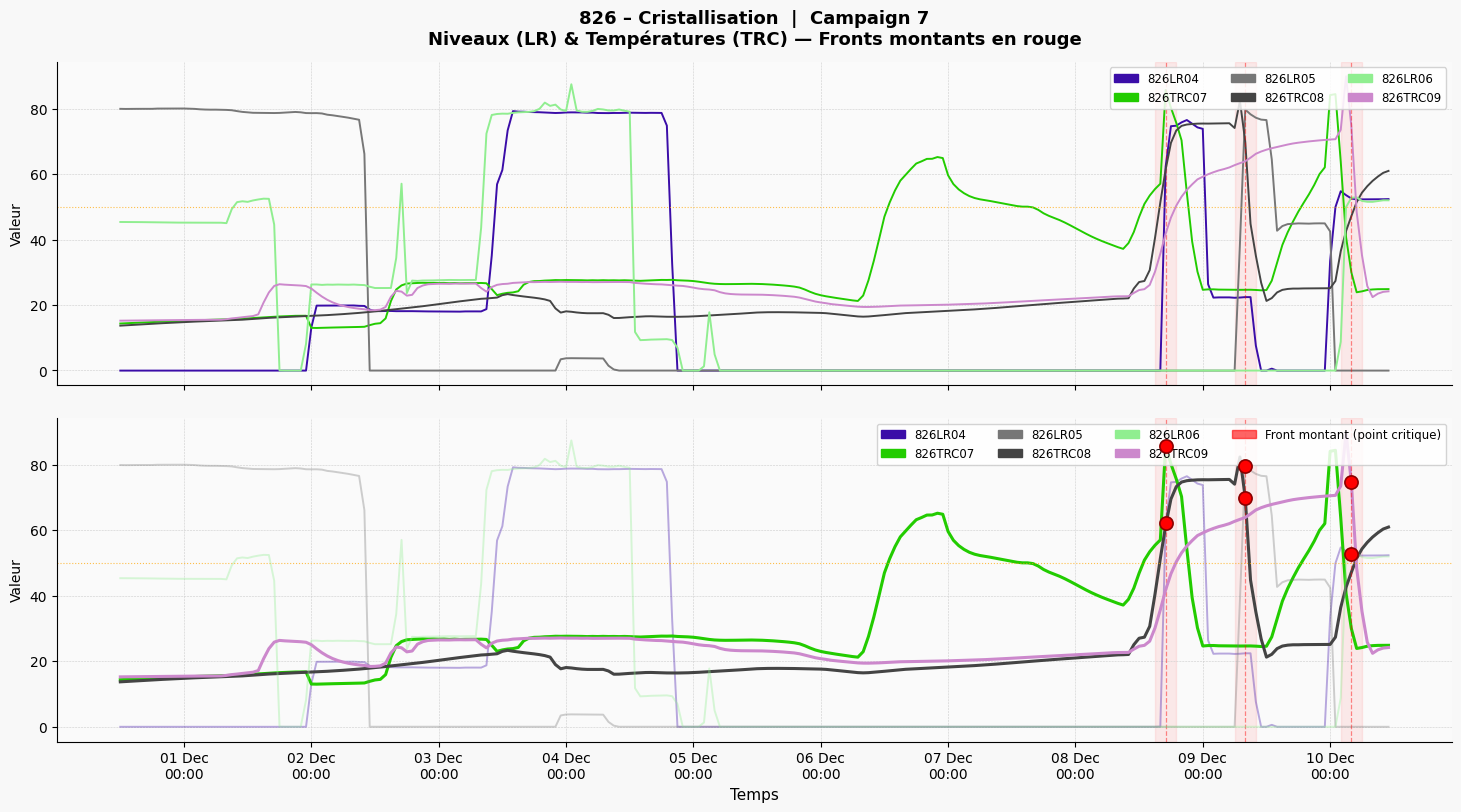


📋 Fronts détectés — Campaign 7
  Cristalliseur 1 : 1 front(s)
    → 2025-12-08 17:00  |  LR=62.2%  TRC=85.7°C
  Cristalliseur 2 : 1 front(s)
    → 2025-12-09 08:00  |  LR=79.7%  TRC=70.0°C
  Cristalliseur 3 : 1 front(s)
    → 2025-12-10 04:00  |  LR=52.7%  TRC=74.6°C


In [ ]:
camp = "Campaign 7"

res = all_results[camp]

fig = plot_campaign(camp, res["df"], res["fronts"])
plt.show()

print(f"\n📋 Fronts détectés — {camp}")

df = res["df"]

for cryst, idxs in res["fronts"].items():
    print(f"  {cryst} : {len(idxs)} front(s)")

    lr_col  = CRYSTALLIZERS[cryst]["lr"]
    trc_col = CRYSTALLIZERS[cryst]["trc"]

    for idx in idxs:
        if idx >= len(df):
            continue

        row = df.iloc[idx]

        print(
            f"    → {str(row['ts'])[:16]}  |  "
            f"LR={row[lr_col]:.1f}%  |  TRC={row[trc_col]:.1f}°C"
        )

### Campaign 8  ·  janvier – mars 2026

La Campaign 8 est de loin la **plus longue et la plus intensive** (~7 semaines, 1128 heures).  
Le **Cristalliseur 1** (LR04/TRC07) est le plus sollicité avec 8 fronts détectés.  
On observe une **pause de production** entre mi-janvier et début février (aucun front),  
puis une **période d'activité intense** de mi-février à début mars avec des fronts rapprochés (~3 jours d'intervalle).


C:\Users\MohamedNadirHAMOU\AppData\Local\Temp\ipykernel_12948\3650013396.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


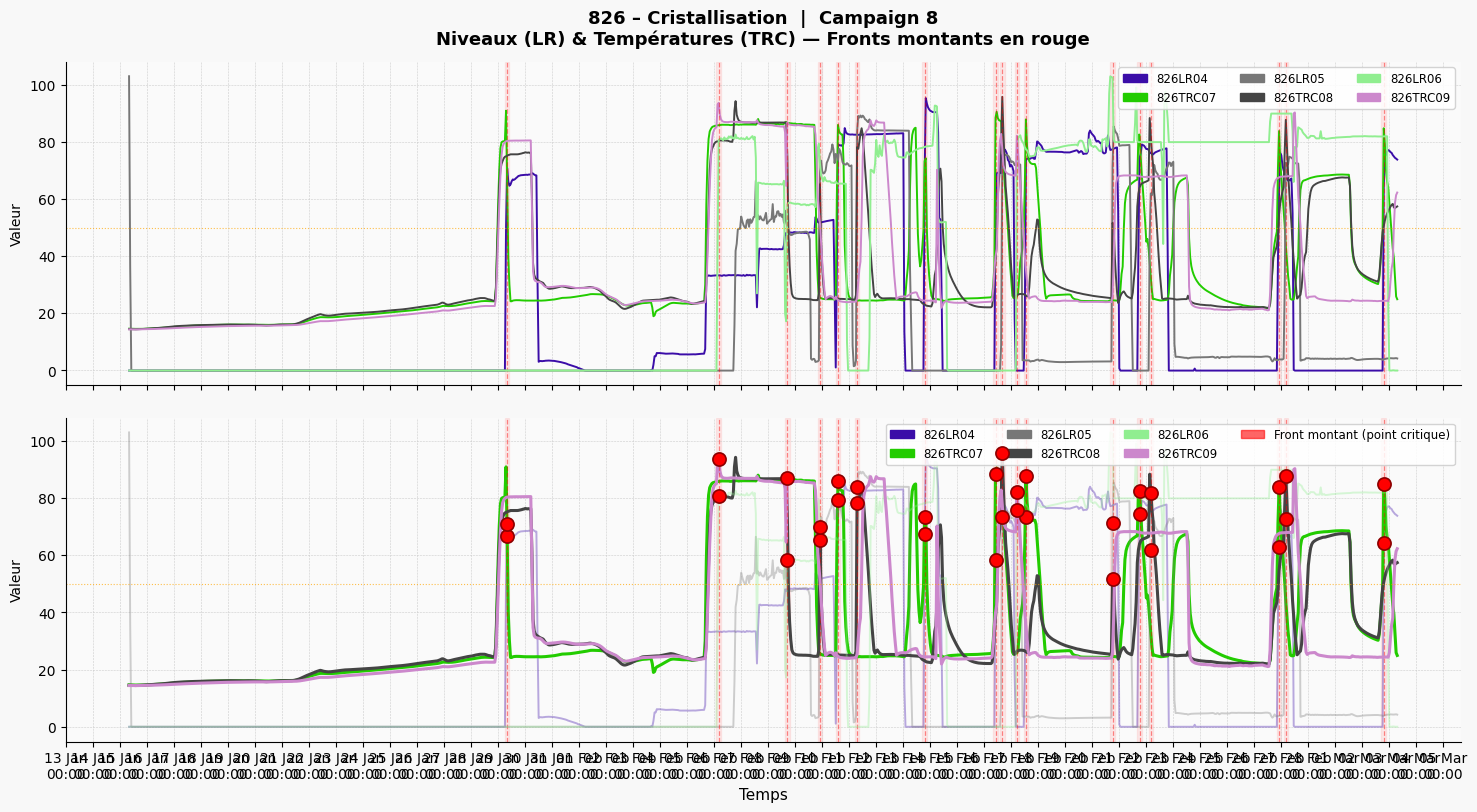


📋 Fronts détectés — Campaign 8
  Cristalliseur 1 : 8 front(s)
    → 2026-01-29 08:00  |  LR=71.0%  TRC=66.9°C
    → 2026-02-10 14:00  |  LR=79.3%  TRC=86.0°C
    → 2026-02-13 19:00  |  LR=67.6%  TRC=73.4°C
    → 2026-02-16 10:00  |  LR=58.3%  TRC=88.5°C
    → 2026-02-17 13:00  |  LR=73.6%  TRC=88.0°C
    → 2026-02-21 18:00  |  LR=74.4%  TRC=82.6°C
    → 2026-02-26 22:00  |  LR=62.9%  TRC=83.9°C
    → 2026-03-02 19:00  |  LR=64.4%  TRC=84.9°C
  Cristalliseur 2 : 6 front(s)
    → 2026-02-09 22:00  |  LR=69.8%  TRC=65.3°C
    → 2026-02-11 07:00  |  LR=83.8%  TRC=78.3°C
    → 2026-02-16 16:00  |  LR=73.5%  TRC=95.9°C
    → 2026-02-20 18:00  |  LR=71.5%  TRC=51.7°C
    → 2026-02-22 04:00  |  LR=62.0%  TRC=81.9°C
    → 2026-02-27 04:00  |  LR=72.7%  TRC=87.8°C
  Cristalliseur 3 : 3 front(s)
    → 2026-02-06 04:00  |  LR=80.8%  TRC=93.8°C
    → 2026-02-08 17:00  |  LR=58.3%  TRC=87.0°C
    → 2026-02-17 05:00  |  LR=76.0%  TRC=82.3°C


In [ ]:
camp = "Campaign 8"

res = all_results[camp]

fig = plot_campaign(camp, res["df"], res["fronts"])
plt.show()

print(f"\n📋 Fronts détectés — {camp}")

df = res["df"]

for cryst, idxs in res["fronts"].items():
    print(f"  {cryst} : {len(idxs)} front(s)")

    lr_col  = CRYSTALLIZERS[cryst]["lr"]
    trc_col = CRYSTALLIZERS[cryst]["trc"]

    for idx in idxs:
        if idx >= len(df):
            continue

        row = df.iloc[idx]

        print(
            f"    → {str(row['ts'])[:16]}  |  "
            f"LR={row[lr_col]:.1f}%  |  TRC={row[trc_col]:.1f}°C"
        )

## 6. Synthèse Globale

Le tableau ci-dessous consolide tous les fronts détectés sur l'ensemble des campagnes,  
et calcule les **statistiques de température et de niveau** au moment du front.


In [ ]:
records = []

for camp_name, res in all_results.items():
    df = res["df"]

    for cryst_name, idxs in res["fronts"].items():
        tags = CRYSTALLIZERS[cryst_name]
        lr_col  = tags["lr"]
        trc_col = tags["trc"]

        for idx in idxs:
            if idx >= len(df):
                continue

            row = df.iloc[idx]

            records.append({
                "Campagne": camp_name,
                "Cristalliseur": cryst_name,
                "Timestamp": str(row["ts"])[:16],
                "LR au front (%)": round(row[lr_col], 1),
                "TRC au front (°C)": round(row[trc_col], 1),
            })

summary = pd.DataFrame(records)
display(summary)

print(f"\n{'='*55}")
print(f"  Total fronts détectés : {len(summary)}")

if len(summary) > 0:
    print(f"  LR moyen au front     : {summary['LR au front (%)'].mean():.1f}%")
    print(f"  TRC moyenne au front  : {summary['TRC au front (°C)'].mean():.1f}°C")
    print(f"  TRC min / max         : {summary['TRC au front (°C)'].min():.1f}°C  /  {summary['TRC au front (°C)'].max():.1f}°C")
else:
    print("  Aucun front détecté")

,Campagne,Cristalliseur,Timestamp,LR au front (%),TRC au front (°C)
0,Campaign 5,Cristalliseur 1,2025-08-30 09:00,53.7,85.4
1,Campaign 5,Cristalliseur 1,2025-09-01 20:00,77.4,82.1
2,Campaign 5,Cristalliseur 1,2025-09-02 12:00,56.0,86.3
3,Campaign 5,Cristalliseur 1,2025-09-03 20:00,68.8,74.3
4,Campaign 5,Cristalliseur 1,2025-09-04 19:00,71.1,76.5
5,Campaign 5,Cristalliseur 2,2025-08-30 20:00,54.6,83.9
6,Campaign 5,Cristalliseur 2,2025-09-02 05:00,74.2,73.2
7,Campaign 5,Cristalliseur 2,2025-09-02 21:00,73.0,82.2
8,Campaign 5,Cristalliseur 3,2025-08-29 20:00,72.3,100.5
9,Campaign 5,Cristalliseur 3,2025-08-31 06:00,63.7,90.5



  Total fronts détectés : 37
  LR moyen au front     : 69.7%
  TRC moyenne au front  : 80.9°C
  TRC min / max         : 51.7°C  /  100.5°C


### Distribution des fronts dans le temps

Ce graphique en barres montre la **répartition des fronts montants** par cristalliseur et par campagne,  
permettant d'identifier rapidement les cristalliseurs les plus sollicités.


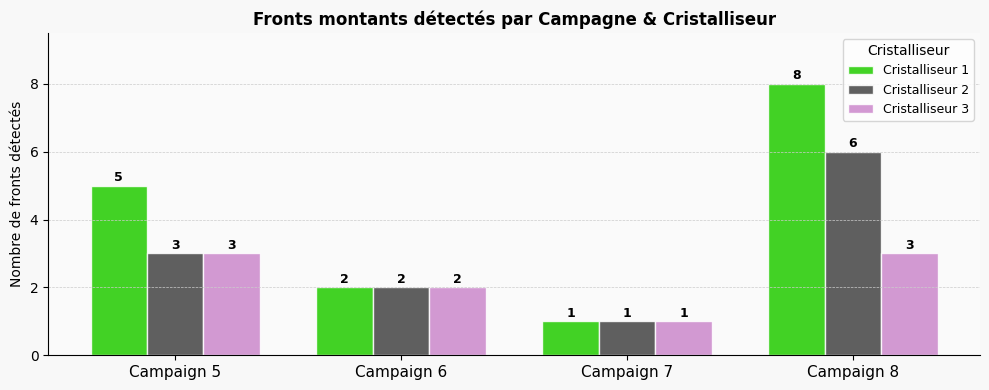

In [ ]:
pivot = summary.groupby(["Campagne", "Cristalliseur"]).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 4))
fig.patch.set_facecolor("#F8F8F8")
ax.set_facecolor("#FAFAFA")

x = np.arange(len(pivot))
width = 0.25

colors = [COLORS_TRC[0], COLORS_TRC[1], COLORS_TRC[2]]

for i, col in enumerate(pivot.columns):
    bars = ax.bar(
        x + i * width,
        pivot[col],
        width,
        label=col,
        color=colors[i % len(colors)],
        alpha=0.85,
        edgecolor="white"
    )

    for bar in bars:
        h = bar.get_height()
        if h > 0:
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                h + 0.05,
                str(int(h)),
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold"
            )

ax.set_xticks(x + width * (len(pivot.columns) - 1) / 2)
ax.set_xticklabels(pivot.index, fontsize=11)

ax.set_ylabel("Nombre de fronts détectés", fontsize=10)
ax.set_title("Fronts montants détectés par Campagne & Cristalliseur",
             fontsize=12, fontweight="bold")

ax.legend(title="Cristalliseur", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", linewidth=0.5, color="#CCCCCC")
ax.set_ylim(0, pivot.values.max() + 1.5)

plt.tight_layout()
plt.show()

## 7. Conclusions & Recommandations

### Ce qui fonctionne bien

- L'algorithme détecte de manière **fiable et reproductible** les fronts montants sur les 4 campagnes
- La signature LR × TRC est **cohérente** : à chaque front, on retrouve une montée de température >5°C/h suivie d'un pic entre 70 et 90°C
- La **Campaign 8** confirme la robustesse sur une longue durée (7 semaines, 17 fronts toutes unités confondues)

### Paramètres ajustables

| Paramètre | Valeur actuelle | Rôle |
|-----------|----------------|------|
| `LR_THRESHOLD` | 50% | Seuil de franchissement du niveau |
| `TRC_SURGE_RATE` | 5.0 °C/h | Vitesse minimale de montée thermique |
| `WINDOW_BEFORE` | 2h | Fenêtre de contexte avant le front |
| `WINDOW_AFTER` | 2h | Fenêtre de contexte après le front |

### Pistes d'amélioration

1. **Validation terrain** : Comparer les timestamps détectés avec les logs opérateurs pour mesurer la précision
2. **Affiner les seuils** : Un seuil `TRC_SURGE_RATE` à 8°C/h pourrait réduire les éventuels faux positifs
3. **Détection de fin de cycle** : Ajouter la détection de la descente de TRC sous 30°C (fin de cristallisation)
4. **Export automatique** : Générer un CSV récapitulatif des fronts avec leurs caractéristiques pour intégration SCADA/MES
